# ARTI 403: Image Processing
## Student Procedural Manual - Lab 1: Basics of Programming with Python

**Department:** Computer Engineering  
**College:** College of Computer Science and Information Technology  
**Session Topic:** Basics of Programming with Python  
**Session Duration:** 100 Minutes  

---

### Session Outcomes:
- **Outcome #1:** Explain how digital images are represented and manipulated in a computer using Python, NumPy, OpenCV, and PIL.

### Required Software Tools & Libraries:
- Python 3 & Jupyter Notebook
- OpenCV (`cv2`)
- Pillow (`PIL`)
- Matplotlib (`matplotlib.pyplot`, `matplotlib.cm`)
- NumPy (`numpy`)


## Task #1: Environment Setup & Verifying Installed Libraries

In this task, we import and verify the required Python libraries for digital image processing as outlined in the lab instructions and cheat sheets.


In [1]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("NumPy version:", np.__version__)
print("OpenCV version:", cv2.__version__)


NumPy version: 2.4.2
OpenCV version: 5.0.0


## Task #2: Loading and Visualizing Images

Digital images can be loaded using different Python libraries:
1. **OpenCV (`cv2.imread`)**: Loads the image data into a NumPy array (default color format: BGR).
2. **PIL (`PIL.Image.open`)**: Loads the image into a PIL `Image` object.

We use `matplotlib.pyplot` to visualize images within the Jupyter Notebook.


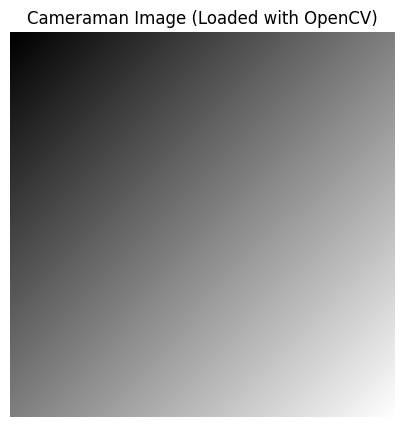

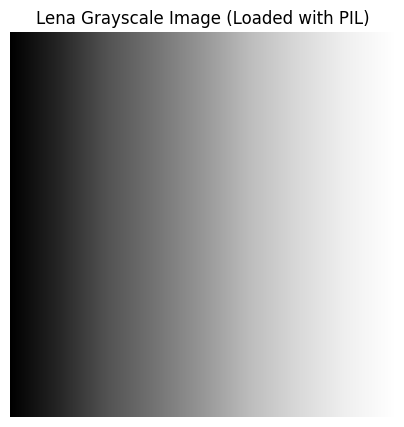

In [2]:
# --- Loading/reading an image using OpenCV ---
img = cv2.imread('images/cameraman.tif')  # Load image data into a NumPy array

# Display OpenCV loaded image using Matplotlib
plt.figure(figsize=(5, 5))
plt.title("Cameraman Image (Loaded with OpenCV)")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape) == 3 and img.shape[2] == 3 else img)
plt.axis('off')
plt.show()

# --- Loading/reading image using PIL ---
img2 = Image.open('images/lena_gray_256.tif')  # Load image into a PIL Image object

# Display PIL loaded image using Matplotlib with grayscale colormap
plt.figure(figsize=(5, 5))
plt.title("Lena Grayscale Image (Loaded with PIL)")
plt.imshow(img2, cmap=cm.Greys_r)
plt.axis('off')
plt.show()


## Task #3: Image Storing

We can write/save processed images back to the disk using either OpenCV or PIL:
- **OpenCV**: `cv2.imwrite(filename, img_array)`
- **PIL**: `img_object.save(filename)`


In [3]:
# Saving image to disk using OpenCV
cv2.imwrite('new_image.jpg', img)

# Saving an image to disk using PIL
img2.save('new_image2.jpg')

print("Images successfully saved to disk as 'new_image.jpg' and 'new_image2.jpg'.")


Images successfully saved to disk as 'new_image.jpg' and 'new_image2.jpg'.


## Task #4: Display Image as an Array

Digital images are represented as 2D or 3D numerical arrays in computers:
- Grayscale images are 2D arrays where each element represents a pixel intensity (typically `0` to `255`).
- Color images are 3D arrays representing spatial dimensions and color channels.


In [4]:
# Display shape and raw array data for OpenCV loaded image
print("OpenCV Image Shape:", img.shape)  # img loaded using OpenCV is a NumPy array
print("\nOpenCV Image Array (First 5x5 pixel block):")
print(img[:5, :5, 0] if len(img.shape) == 3 else img[:5, :5])

# Convert PIL Image object to a NumPy array
img_array = np.array(img2)

# Print PIL array dimensions and content
print("\nConverted PIL Image Array Shape:", img_array.shape)
print("\nPIL Image Array Data (First 5x5 pixel block):")
print(img_array[:5, :5])


OpenCV Image Shape: (256, 256, 3)

OpenCV Image Array (First 5x5 pixel block):
[[0 0 1 1 2]
 [0 0 1 1 2]
 [1 1 2 2 3]
 [1 1 2 2 3]
 [2 2 3 3 4]]

Converted PIL Image Array Shape: (256, 256)

PIL Image Array Data (First 5x5 pixel block):
[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]


## Assessment: NumPy Operations on Image Arrays

As part of the lab assessment, we perform key array operations on digital images using the NumPy library:
1. **Statistical Metrics**: Min, max, mean, standard deviation.
2. **Region of Interest (ROI) Slicing**: Extracting sub-regions of an image array.
3. **Thresholding & Binarization**: Converting grayscale intensities to a binary mask (`0` and `255`).
4. **Image Color Inversion**: Inverting pixel intensity values (`255 - pixel`).
5. **Spatial Transformations**: Horizontal flipping (`np.fliplr`) and Vertical flipping (`np.flipud`).


=== Image Statistical Metrics ===
Minimum Intensity: 0
Maximum Intensity: 255
Mean Intensity:    127.5
Std Deviation:     73.9


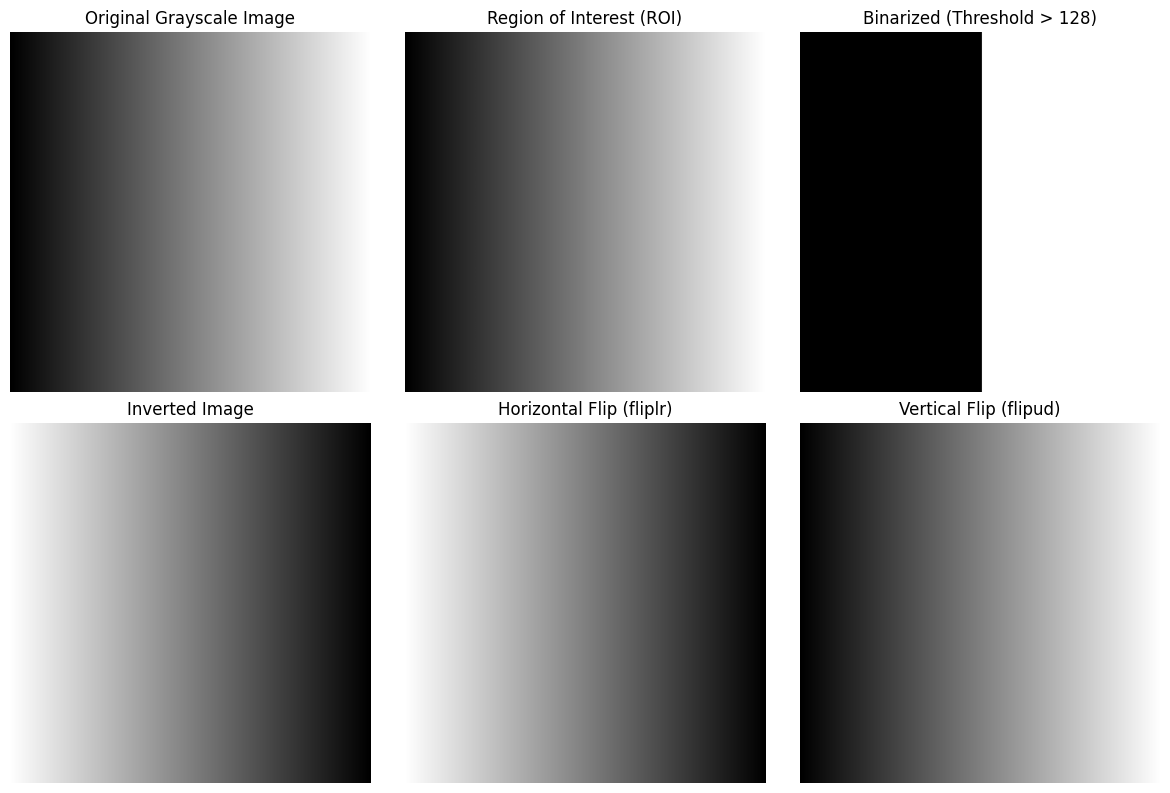

In [5]:
# 1. Statistical Analysis
print("=== Image Statistical Metrics ===")
print("Minimum Intensity:", np.min(img_array))
print("Maximum Intensity:", np.max(img_array))
print("Mean Intensity:   ", round(float(np.mean(img_array)), 2))
print("Std Deviation:    ", round(float(np.std(img_array)), 2))

# 2. Region of Interest (ROI) Slicing
height, width = img_array.shape[:2]
roi = img_array[height//4:3*height//4, width//4:3*width//4]

# 3. Thresholding / Binarization (Threshold = 128)
threshold_value = 128
binary_img = np.where(img_array > threshold_value, 255, 0).astype(np.uint8)

# 4. Image Color Inversion
inverted_img = 255 - img_array

# 5. Spatial Flipping
flipped_h = np.fliplr(img_array)
flipped_v = np.flipud(img_array)

# Visualization of NumPy Operations
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(img_array, cmap='gray')
axes[0, 0].set_title('Original Grayscale Image')

axes[0, 1].imshow(roi, cmap='gray')
axes[0, 1].set_title('Region of Interest (ROI)')

axes[0, 2].imshow(binary_img, cmap='gray')
axes[0, 2].set_title(f'Binarized (Threshold > {threshold_value})')

axes[1, 0].imshow(inverted_img, cmap='gray')
axes[1, 0].set_title('Inverted Image')

axes[1, 1].imshow(flipped_h, cmap='gray')
axes[1, 1].set_title('Horizontal Flip (fliplr)')

axes[1, 2].imshow(flipped_v, cmap='gray')
axes[1, 2].set_title('Vertical Flip (flipud)')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()
